# Rain Sound Detection
## Binary Audio Classification: Rain vs No-Rain

A CNN-based classifier trained on 4-second audio clips using mel-spectrogram features.

---
### Sections
1. [Dataset Exploration & Visualisation](#1)
2. [Data Preprocessing & Feature Extraction](#2)
3. [Model Definition & Training](#3)
4. [Results & Evaluation](#4)

In [1]:
import sys
print(sys.executable)

/home/amani/phd/.venv/bin/python


In [2]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
sns.set_style("whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

DATA_ROOT   = Path("/home/amani/phd/rain_detection/processed_binary_4s")
RAIN_DIR    = DATA_ROOT / "rain"
NO_RAIN_DIR = DATA_ROOT / "no_rain"

# --- audio params ---
# --- audio params ---
SR          = 44100   # ✅ changed
DURATION    = 4.0
N_MELS      = 64
N_FFT       = 2048    # ✅ doubled (was 1024)
HOP_LENGTH  = 1024    # ✅ doubled (was 512)
FMIN        = 20
FMAX        = 22050   # ✅ changed to Nyquist of 44100 (was 8000)
# --- training hyper-params ---
BATCH_SIZE  = 32
EPOCHS      = 40
LR          = 3e-4
WEIGHT_DECAY= 1e-4

Device: cuda


## 1 · Dataset Exploration & Visualisation <a id="1"></a>

Total clips  : 2652
  rain       : 1444
  no_rain    : 1208

Class balance ratio  : 54.45% rain


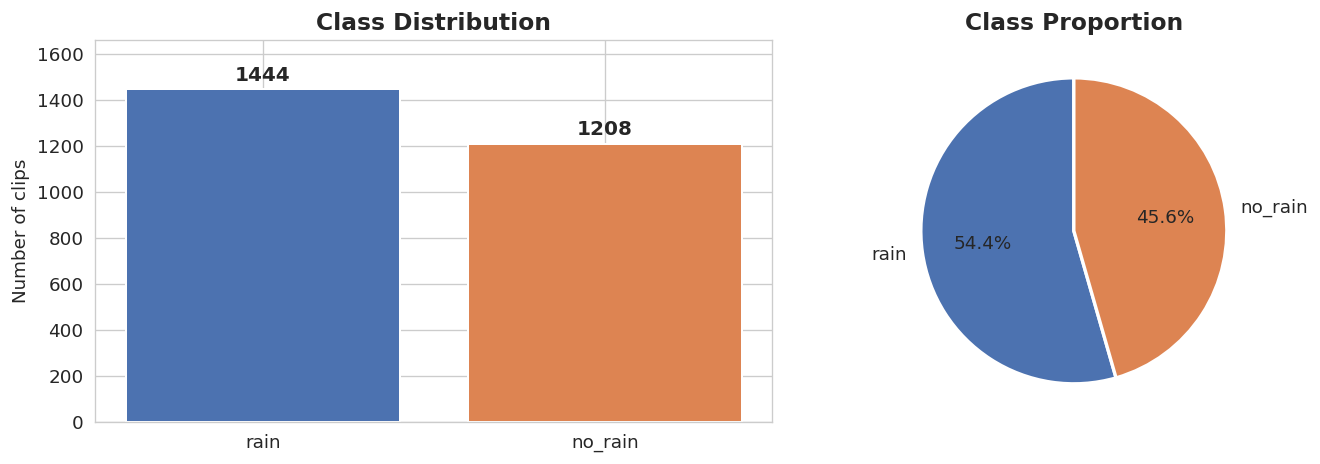

,path,label,label_id
0,/home/amani/phd/rain_detection/processed_binar...,rain,1
1,/home/amani/phd/rain_detection/processed_binar...,rain,1
2,/home/amani/phd/rain_detection/processed_binar...,rain,1
3,/home/amani/phd/rain_detection/processed_binar...,rain,1
4,/home/amani/phd/rain_detection/processed_binar...,rain,1


In [3]:
### 1.1 — File inventory & class balance

rain_files    = sorted(RAIN_DIR.glob("*.wav"))
no_rain_files = sorted(NO_RAIN_DIR.glob("*.wav"))

df = pd.DataFrame(
    [(str(p), "rain")    for p in rain_files] +
    [(str(p), "no_rain") for p in no_rain_files],
    columns=["path", "label"]
)
df["label_id"] = df["label"].map({"rain": 1, "no_rain": 0})

print(f"Total clips  : {len(df)}")
print(f"  rain       : {(df.label=='rain').sum()}")
print(f"  no_rain    : {(df.label=='no_rain').sum()}")
print(f"\nClass balance ratio  : {(df.label=='rain').mean():.2%} rain")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# class count bar
counts = df.label.value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=["#4C72B0", "#DD8452"], edgecolor="white", linewidth=1.2)
axes[0].bar_label(bars, padding=3, fontsize=12, fontweight="bold")
axes[0].set_title("Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Number of clips")
axes[0].set_ylim(0, counts.max() * 1.15)

# pie
axes[1].pie(counts.values, labels=counts.index,
            autopct="%1.1f%%", colors=["#4C72B0", "#DD8452"],
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Class Proportion", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()
df.head()

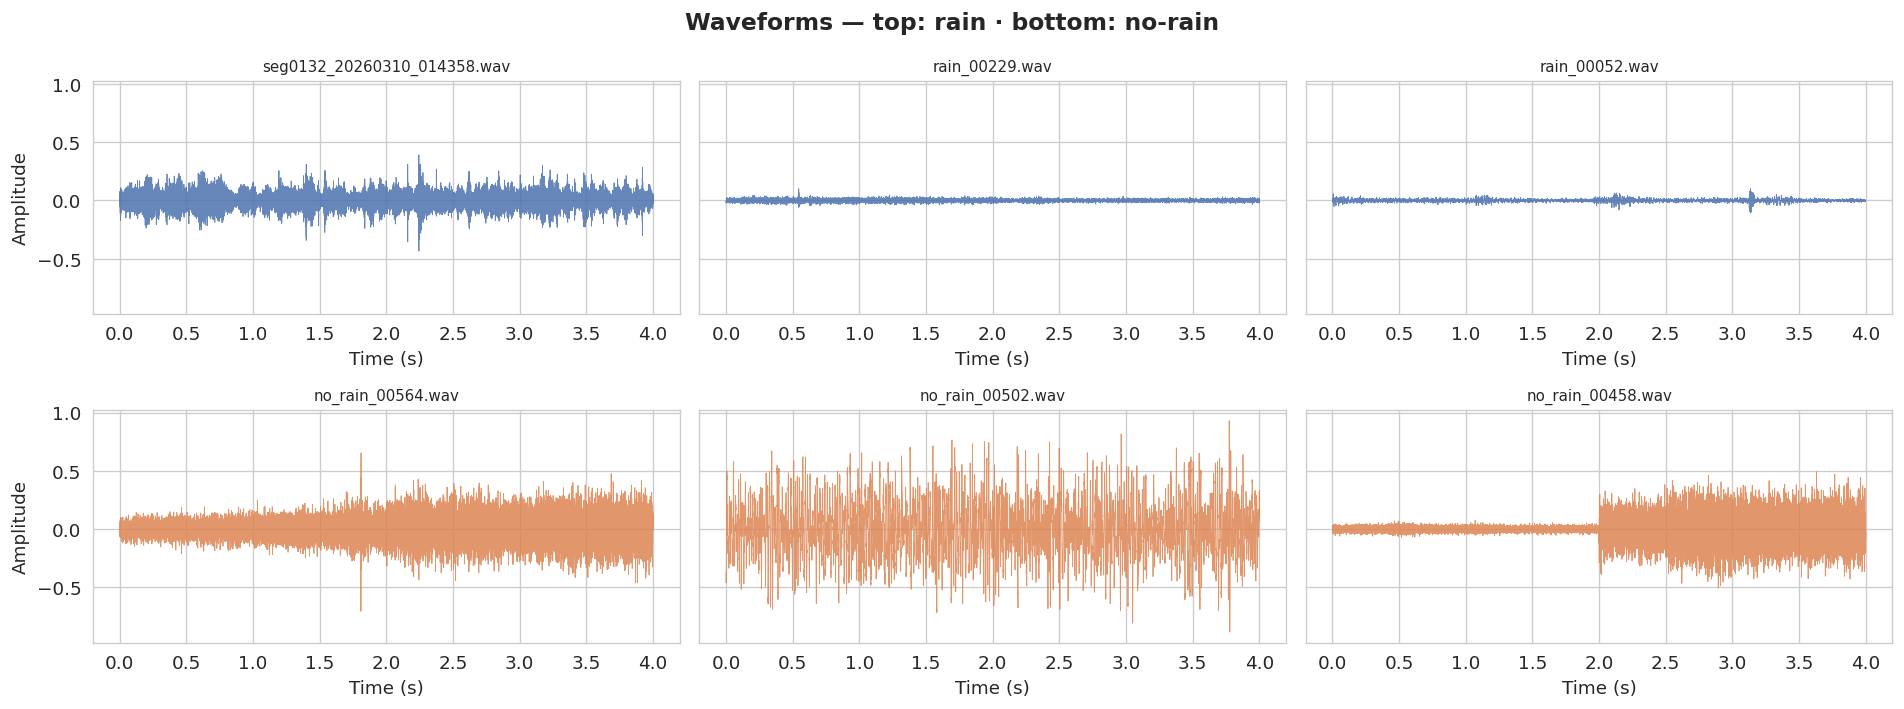

In [4]:
### 1.2 — Waveform comparison (3 examples per class)

def load_wave(path):
    y, _ = librosa.load(path, sr=SR, duration=DURATION, mono=True)
    if len(y) < int(SR * DURATION):
        y = np.pad(y, (0, int(SR * DURATION) - len(y)))
    return y

rain_samples    = random.sample(rain_files, 3)
no_rain_samples = random.sample(no_rain_files, 3)

t = np.linspace(0, DURATION, int(SR * DURATION))

fig, axes = plt.subplots(2, 3, figsize=(16, 6), sharey=True)
fig.suptitle("Waveforms — top: rain · bottom: no-rain", fontsize=14, fontweight="bold")

for i, fp in enumerate(rain_samples):
    y = load_wave(fp)
    axes[0, i].plot(t, y, color="#4C72B0", linewidth=0.5, alpha=0.85)
    axes[0, i].set_title(fp.name, fontsize=9)
    axes[0, i].set_xlabel("Time (s)")
    axes[0, i].set_ylabel("Amplitude" if i == 0 else "")

for i, fp in enumerate(no_rain_samples):
    y = load_wave(fp)
    axes[1, i].plot(t, y, color="#DD8452", linewidth=0.5, alpha=0.85)
    axes[1, i].set_title(fp.name, fontsize=9)
    axes[1, i].set_xlabel("Time (s)")
    axes[1, i].set_ylabel("Amplitude" if i == 0 else "")

plt.tight_layout()
plt.show()

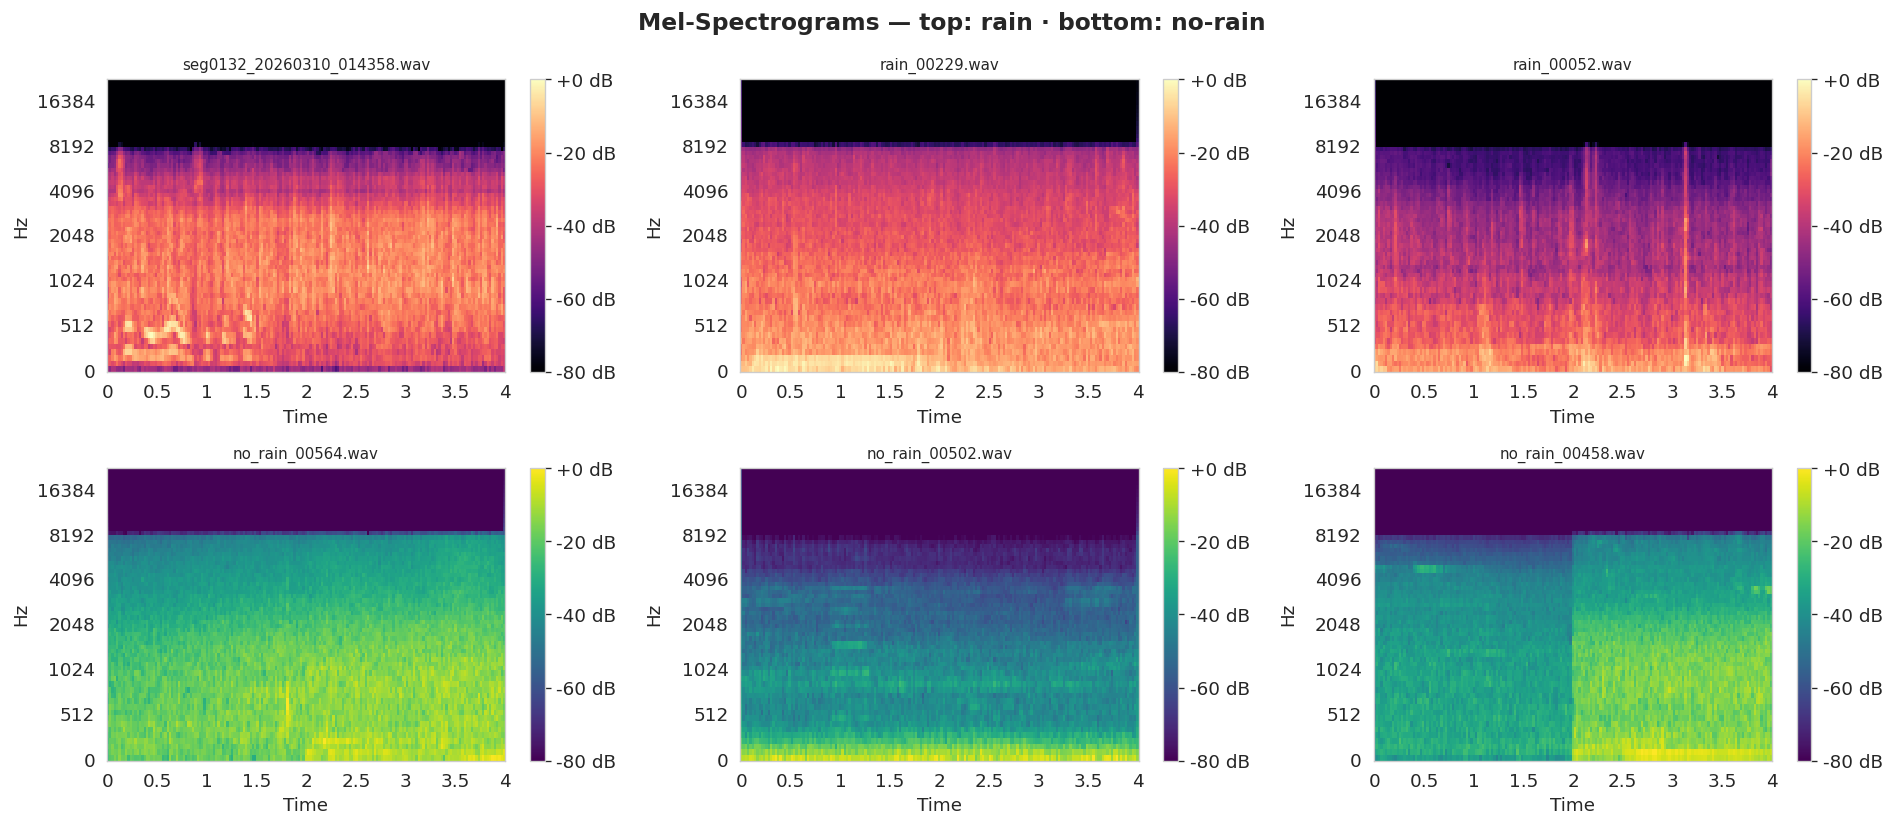

In [5]:
### 1.3 — Mel-spectrogram comparison (3 per class)

def compute_mel(path):
    y = load_wave(path)
    S = librosa.feature.melspectrogram(
        y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX
    )
    return librosa.power_to_db(S, ref=np.max)

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
fig.suptitle("Mel-Spectrograms — top: rain · bottom: no-rain", fontsize=14, fontweight="bold")

for i, fp in enumerate(rain_samples):
    mel = compute_mel(fp)
    img = librosa.display.specshow(mel, sr=SR, hop_length=HOP_LENGTH,
                                   x_axis="time", y_axis="mel",
                                   fmin=FMIN, fmax=FMAX, ax=axes[0, i],
                                   cmap="magma")
    axes[0, i].set_title(fp.name, fontsize=9)
    fig.colorbar(img, ax=axes[0, i], format="%+2.0f dB")

for i, fp in enumerate(no_rain_samples):
    mel = compute_mel(fp)
    img = librosa.display.specshow(mel, sr=SR, hop_length=HOP_LENGTH,
                                   x_axis="time", y_axis="mel",
                                   fmin=FMIN, fmax=FMAX, ax=axes[1, i],
                                   cmap="viridis")
    axes[1, i].set_title(fp.name, fontsize=9)
    fig.colorbar(img, ax=axes[1, i], format="%+2.0f dB")

plt.tight_layout()
plt.show()

            rms             zcr           centroid            bandwidth  \
           mean     std    mean     std       mean       std       mean   
label                                                                     
no_rain  0.0531  0.0597  0.0563  0.0193  1640.5417  338.7072  1463.3105   
rain     0.0278  0.0226  0.0647  0.0271  1924.7328  436.8346  1618.5311   

                   
              std  
label              
no_rain  230.2843  
rain     283.7584  


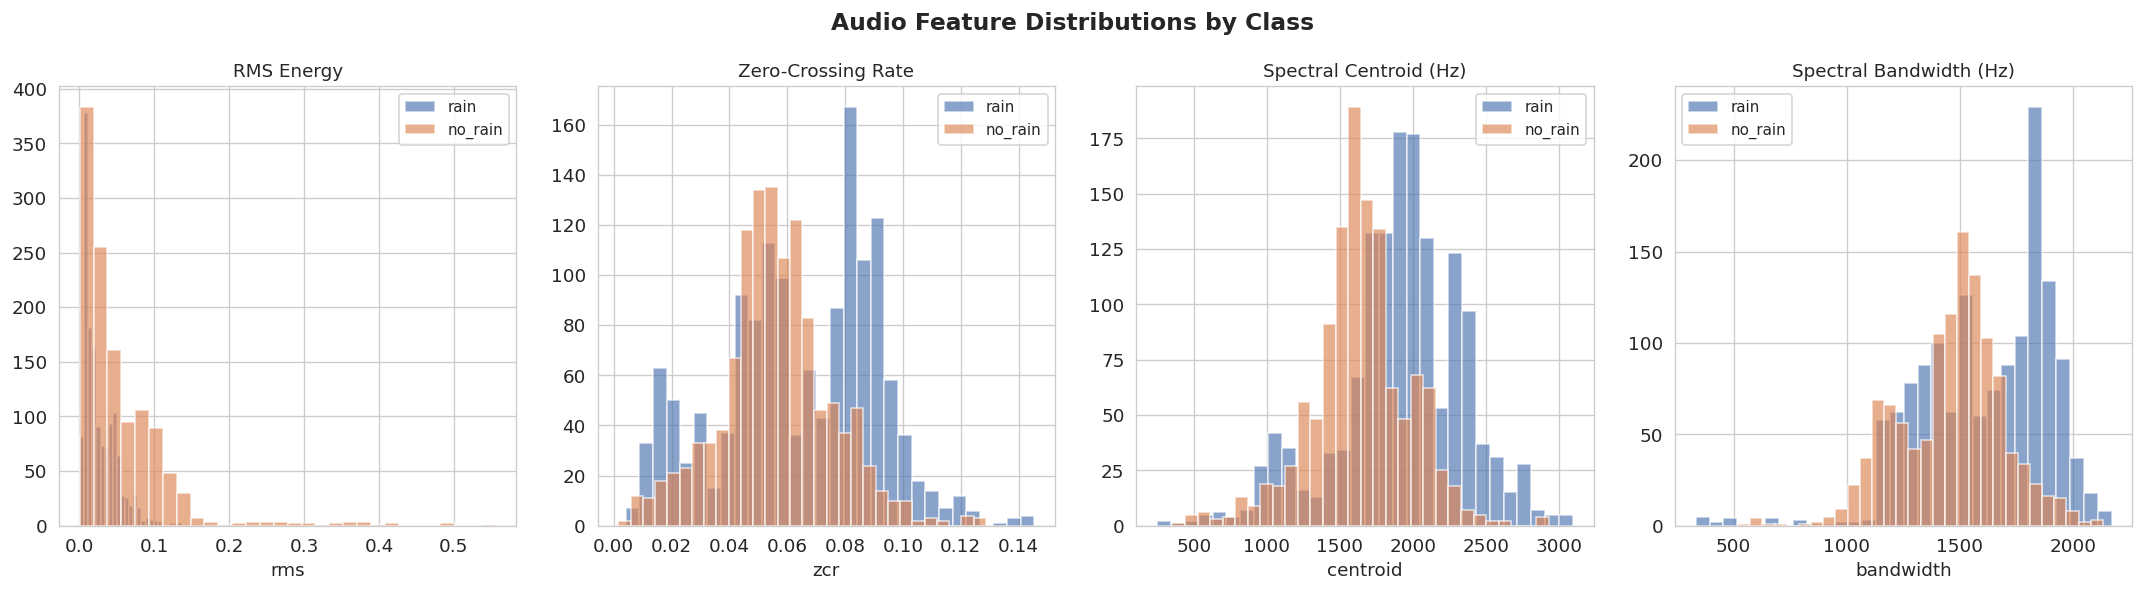

In [6]:
### 1.4 — Audio statistics: RMS energy, spectral centroid, zero-crossing rate

def audio_stats(path):
    y = load_wave(path)
    rms  = float(np.sqrt(np.mean(y**2)))
    zcr  = float(np.mean(librosa.feature.zero_crossing_rate(y)))
    sc   = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=SR)))
    sb   = float(np.mean(librosa.feature.spectral_bandwidth(y=y, sr=SR)))
    return rms, zcr, sc, sb

stats_rows = []
for fp in rain_files:
    rms, zcr, sc, sb = audio_stats(fp)
    stats_rows.append({"label": "rain", "rms": rms, "zcr": zcr, "centroid": sc, "bandwidth": sb})
for fp in no_rain_files:
    rms, zcr, sc, sb = audio_stats(fp)
    stats_rows.append({"label": "no_rain", "rms": rms, "zcr": zcr, "centroid": sc, "bandwidth": sb})

stats_df = pd.DataFrame(stats_rows)
print(stats_df.groupby("label").agg(["mean", "std"]).round(4))

palette = {"rain": "#4C72B0", "no_rain": "#DD8452"}
features = ["rms", "zcr", "centroid", "bandwidth"]
titles   = ["RMS Energy", "Zero-Crossing Rate", "Spectral Centroid (Hz)", "Spectral Bandwidth (Hz)"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Audio Feature Distributions by Class", fontsize=14, fontweight="bold")

for ax, feat, title in zip(axes, features, titles):
    for lbl, color in palette.items():
        vals = stats_df[stats_df.label == lbl][feat]
        ax.hist(vals, bins=30, alpha=0.65, color=color, label=lbl, edgecolor="white")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(feat)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [7]:
### 1.5 — Listen to examples

print("=== RAIN sample ===")
ipd.display(ipd.Audio(str(rain_samples[0]), rate=SR))
print("=== NO-RAIN sample ===")
ipd.display(ipd.Audio(str(no_rain_samples[0]), rate=SR))

=== RAIN sample ===


=== NO-RAIN sample ===


---
## 2 · Data Preprocessing & Feature Extraction <a id="2"></a>

Train : 1856  (rain=1011, no_rain=845)
Val   :  398  (rain=217, no_rain=181)
Test  :  398  (rain=216, no_rain=182)


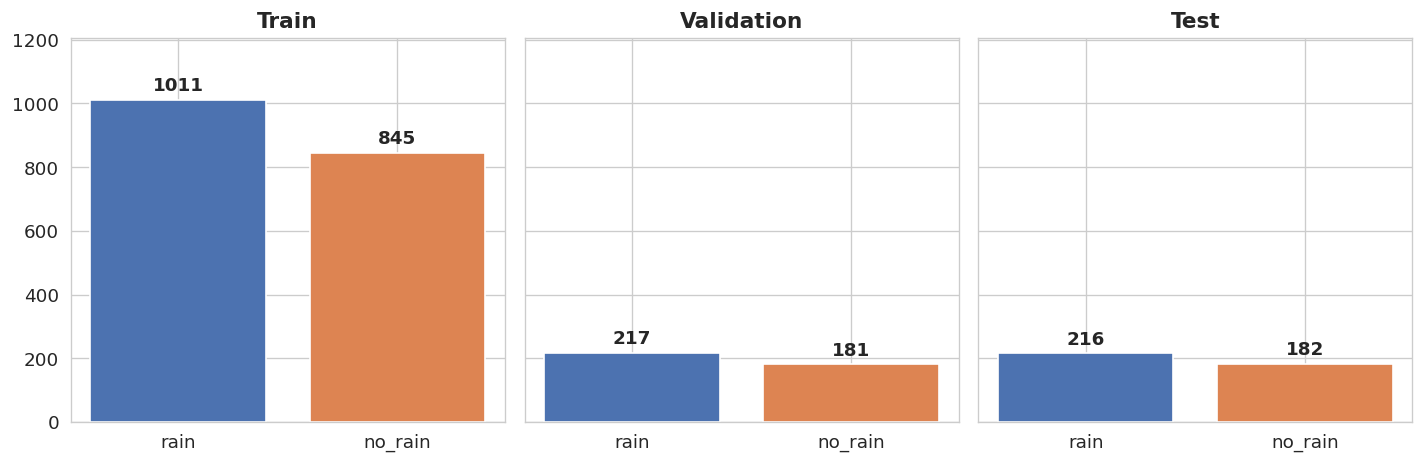

In [8]:
### 2.1 — Train / Validation / Test split (70 / 15 / 15)

train_df, temp_df = train_test_split(df, test_size=0.30,
                                     stratify=df["label_id"], random_state=SEED)
val_df, test_df   = train_test_split(temp_df, test_size=0.50,
                                     stratify=temp_df["label_id"], random_state=SEED)

print(f"Train : {len(train_df):>4}  (rain={train_df.label_id.sum()}, no_rain={(train_df.label_id==0).sum()})")
print(f"Val   : {len(val_df):>4}  (rain={val_df.label_id.sum()}, no_rain={(val_df.label_id==0).sum()})")
print(f"Test  : {len(test_df):>4}  (rain={test_df.label_id.sum()}, no_rain={(test_df.label_id==0).sum()})")

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, split_df, title in zip(axes,
                                [train_df, val_df, test_df],
                                ["Train", "Validation", "Test"]):
    counts = split_df.label.value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=["#4C72B0", "#DD8452"], edgecolor="white")
    ax.bar_label(bars, padding=3, fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylim(0, len(train_df) * 0.65)
plt.tight_layout()
plt.show()

In [9]:
### 2.2 — PyTorch Dataset with on-the-fly mel-spectrogram + augmentation

class RainDataset(Dataset):
    """
    Loads audio clips, computes log-mel spectrogram, and applies
    optional time-masking / frequency-masking augmentation.
    Output shape: (1, N_MELS, T)
    """
    def __init__(self, dataframe, augment=False):
        self.paths   = dataframe["path"].tolist()
        self.labels  = dataframe["label_id"].tolist()
        self.augment = augment
        self.n_samples = int(SR * DURATION)

    def _load(self, path):
        y, _ = librosa.load(path, sr=SR, duration=DURATION, mono=True)
        if len(y) < self.n_samples:
            y = np.pad(y, (0, self.n_samples - len(y)))
        return y.astype(np.float32)

    def _mel(self, y):
        S = librosa.feature.melspectrogram(
            y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
            n_mels=N_MELS, fmin=FMIN, fmax=FMAX
        )
        db = librosa.power_to_db(S, ref=np.max)
        # normalise to [0, 1]
        db = (db - db.min()) / (db.max() - db.min() + 1e-8)
        return db.astype(np.float32)

    def _augment(self, spec):
        """SpecAugment: time mask + frequency mask."""
        spec = spec.copy()
        T, F = spec.shape[1], spec.shape[0]
        # time mask
        t_mask = random.randint(5, 20)
        t0 = random.randint(0, max(0, T - t_mask))
        spec[:, t0:t0 + t_mask] = 0.0
        # freq mask
        f_mask = random.randint(2, 10)
        f0 = random.randint(0, max(0, F - f_mask))
        spec[f0:f0 + f_mask, :] = 0.0
        return spec

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        y    = self._load(self.paths[idx])
        spec = self._mel(y)                          # (N_MELS, T)
        if self.augment:
            spec = self._augment(spec)
        spec = torch.tensor(spec).unsqueeze(0)       # (1, N_MELS, T)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return spec, label


train_ds = RainDataset(train_df, augment=True)
val_ds   = RainDataset(val_df,   augment=False)
test_ds  = RainDataset(test_df,  augment=False)

# weighted sampler to handle any residual imbalance
class_counts = np.bincount(train_df["label_id"].values)
weights      = 1.0 / class_counts[train_df["label_id"].values]
sampler      = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=4, pin_memory=True)

# sanity check
x, y = next(iter(train_loader))
print(f"Batch shape  : {x.shape}")
print(f"Label shape  : {y.shape}")
print(f"Value range  : [{x.min():.3f}, {x.max():.3f}]")

Batch shape  : torch.Size([32, 1, 64, 173])
Label shape  : torch.Size([32])
Value range  : [0.000, 1.000]


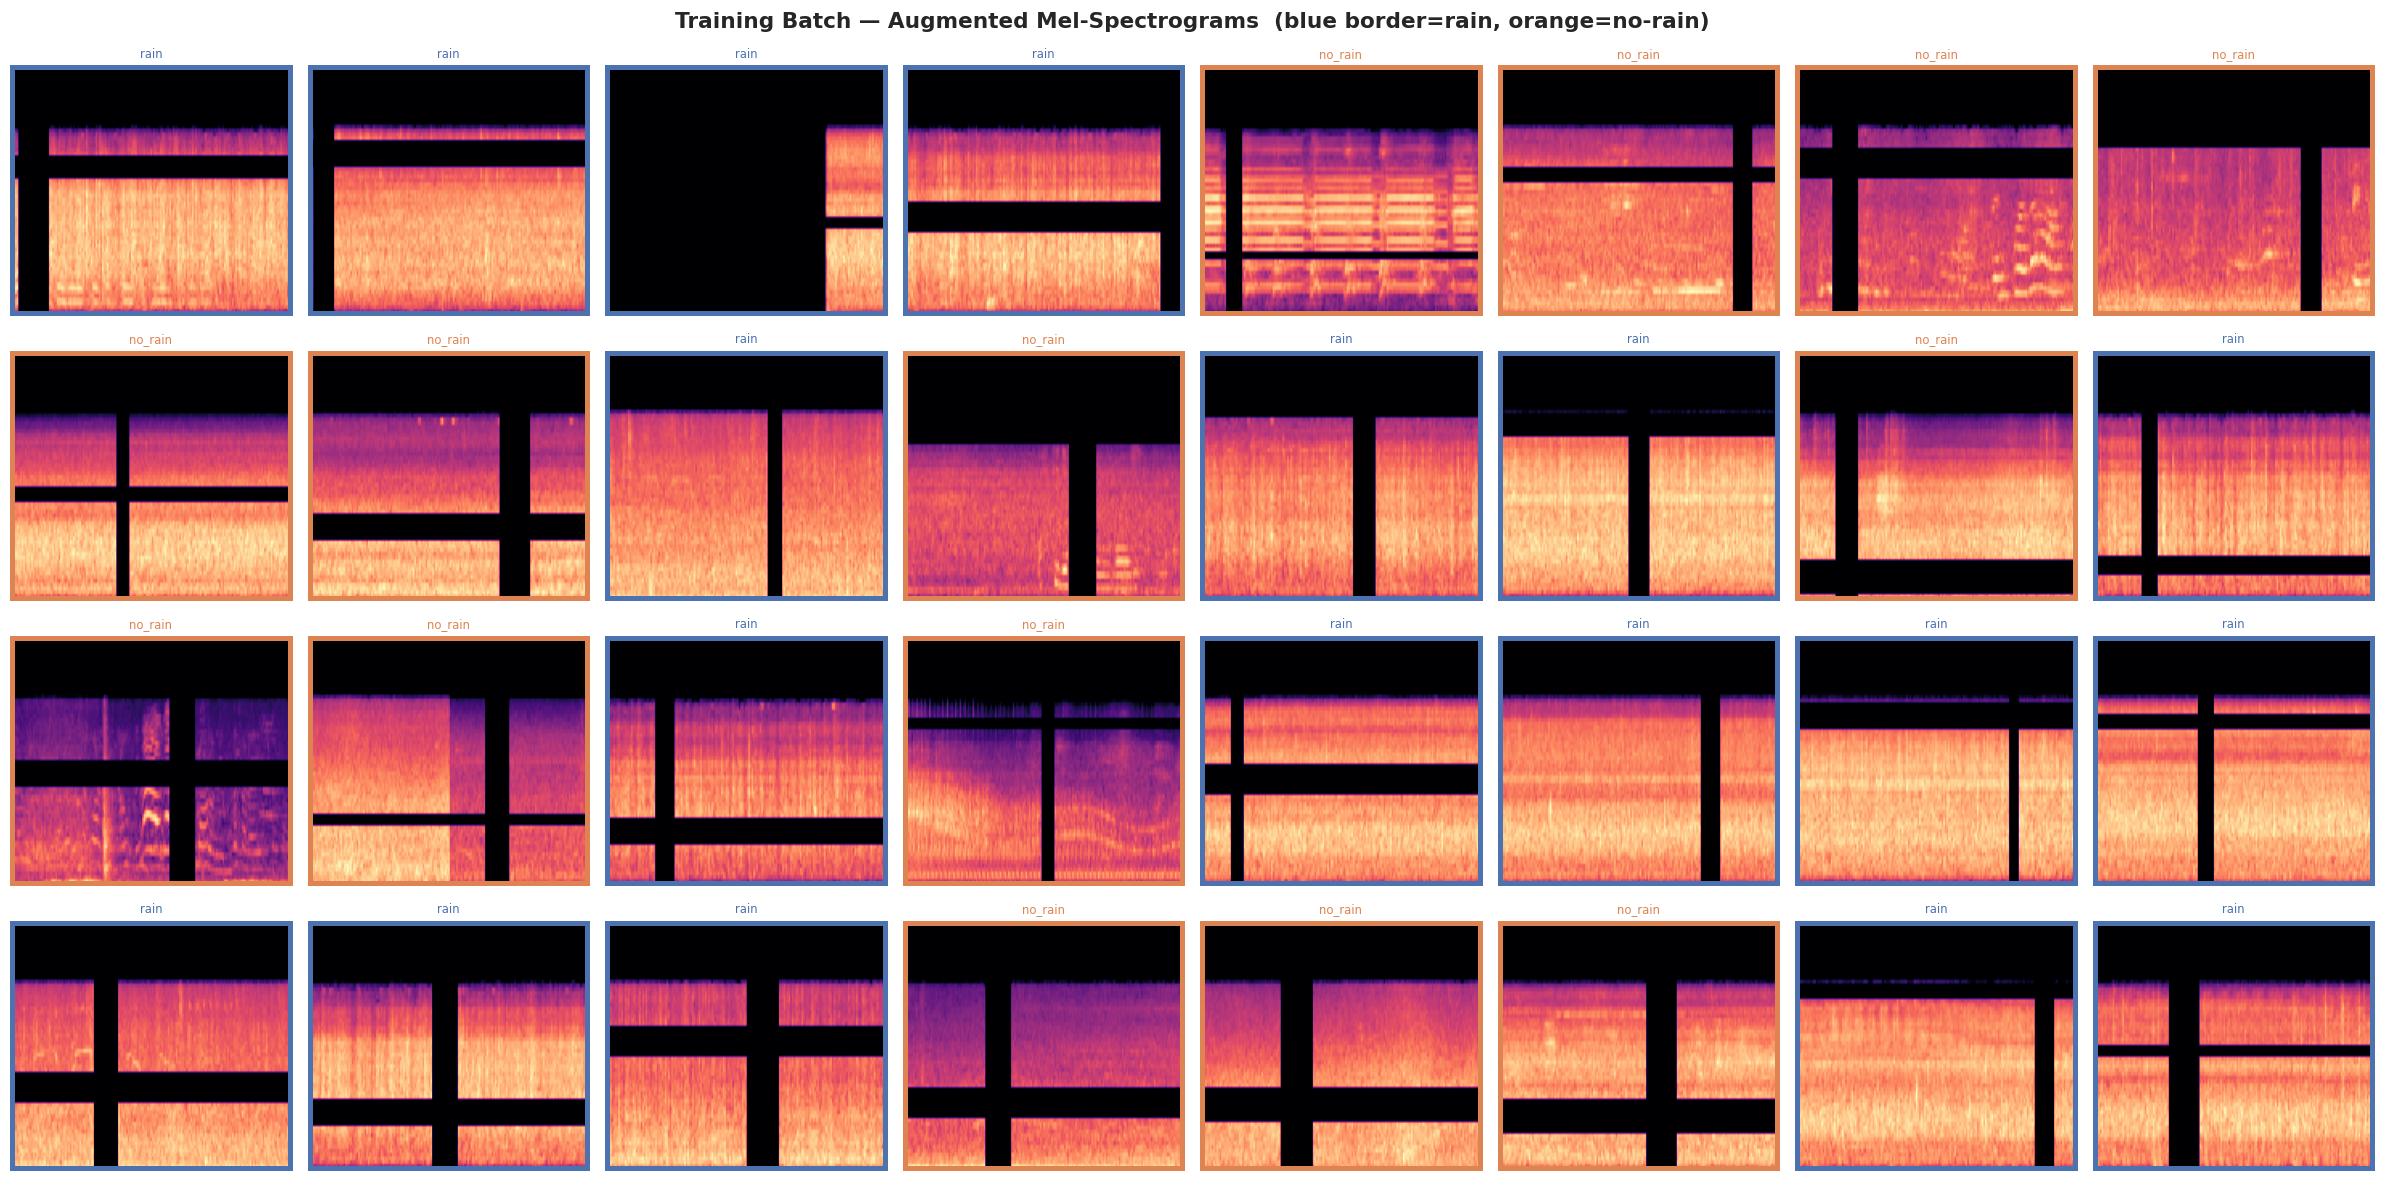

In [10]:
### 2.3 — Visualise a training batch (with augmentation)

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle("Training Batch — Augmented Mel-Spectrograms  (blue border=rain, orange=no-rain)",
             fontsize=13, fontweight="bold")

batch_x, batch_y = next(iter(train_loader))
for i, ax in enumerate(axes.flat):
    if i >= len(batch_x):
        ax.axis("off")
        continue
    spec = batch_x[i, 0].numpy()
    ax.imshow(spec, origin="lower", aspect="auto", cmap="magma")
    lbl = int(batch_y[i].item())
    for spine in ax.spines.values():
        spine.set_edgecolor("#4C72B0" if lbl == 1 else "#DD8452")
        spine.set_linewidth(3)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("rain" if lbl else "no_rain", fontsize=7,
                 color="#4C72B0" if lbl else "#DD8452")

plt.tight_layout()
plt.show()

---
## 3 · Model Definition & Training <a id="3"></a>

In [11]:
### 3.1 — CNN Architecture

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=(2, 2)):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(pool),
            nn.Dropout2d(0.15),
        )
    def forward(self, x):
        return self.block(x)


class RainCNN(nn.Module):
    """
    Lightweight CNN operating on (1, 64, T) log-mel spectrograms.
    4 convolutional blocks → global average pooling → 2-layer MLP → sigmoid
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1,   32, pool=(2, 2)),
            ConvBlock(32,  64, pool=(2, 2)),
            ConvBlock(64,  128, pool=(2, 2)),
            ConvBlock(128, 256, pool=(2, 2)),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, 1),   # raw logit → BCEWithLogitsLoss
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        return self.classifier(x).squeeze(1)


model = RainCNN().to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

RainCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.15, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), pad

In [12]:
### 3.2 — Loss, optimiser, scheduler

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f"Loss      : BCEWithLogitsLoss")
print(f"Optimiser : AdamW  (lr={LR}, wd={WEIGHT_DECAY})")
print(f"Scheduler : CosineAnnealingLR  (T_max={EPOCHS})")

Loss      : BCEWithLogitsLoss
Optimiser : AdamW  (lr=0.0003, wd=0.0001)
Scheduler : CosineAnnealingLR  (T_max=40)


In [13]:
### 3.3 — Training loop

def run_epoch(loader, model, criterion, optimizer=None, device=DEVICE):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss   = criterion(logits, y)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            preds  = (torch.sigmoid(logits) >= 0.5).long()
            correct += (preds == y.long()).sum().item()
            total   += len(y)
            total_loss += loss.item() * len(y)

    return total_loss / total, correct / total


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
best_val_loss = float("inf")
best_ckpt = "/home/amani/phd/rain_detection/rain_cnn_best.pt"

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, model, criterion, optimizer)
    va_loss, va_acc = run_epoch(val_loader,   model, criterion)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model.state_dict(), best_ckpt)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3}/{EPOCHS}  "
              f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
              f"val_loss={va_loss:.4f}  val_acc={va_acc:.4f}")

print(f"\nBest checkpoint saved → {best_ckpt}  (val_loss={best_val_loss:.4f})")

Epoch   1/40  train_loss=0.6537  train_acc=0.6358  val_loss=0.6772  val_acc=0.6181
Epoch   5/40  train_loss=0.3266  train_acc=0.8734  val_loss=0.2636  val_acc=0.8744
Epoch  10/40  train_loss=0.1960  train_acc=0.9262  val_loss=0.1078  val_acc=0.9673
Epoch  15/40  train_loss=0.1339  train_acc=0.9515  val_loss=0.2034  val_acc=0.9121
Epoch  20/40  train_loss=0.0810  train_acc=0.9688  val_loss=0.0384  val_acc=0.9824
Epoch  25/40  train_loss=0.0656  train_acc=0.9752  val_loss=0.0561  val_acc=0.9849
Epoch  30/40  train_loss=0.0476  train_acc=0.9811  val_loss=0.0177  val_acc=0.9874
Epoch  35/40  train_loss=0.0416  train_acc=0.9876  val_loss=0.0303  val_acc=0.9874
Epoch  40/40  train_loss=0.0431  train_acc=0.9871  val_loss=0.0178  val_acc=0.9950

Best checkpoint saved → /home/amani/phd/rain_detection/rain_cnn_best.pt  (val_loss=0.0130)


---
## 4 · Results & Evaluation <a id="4"></a>

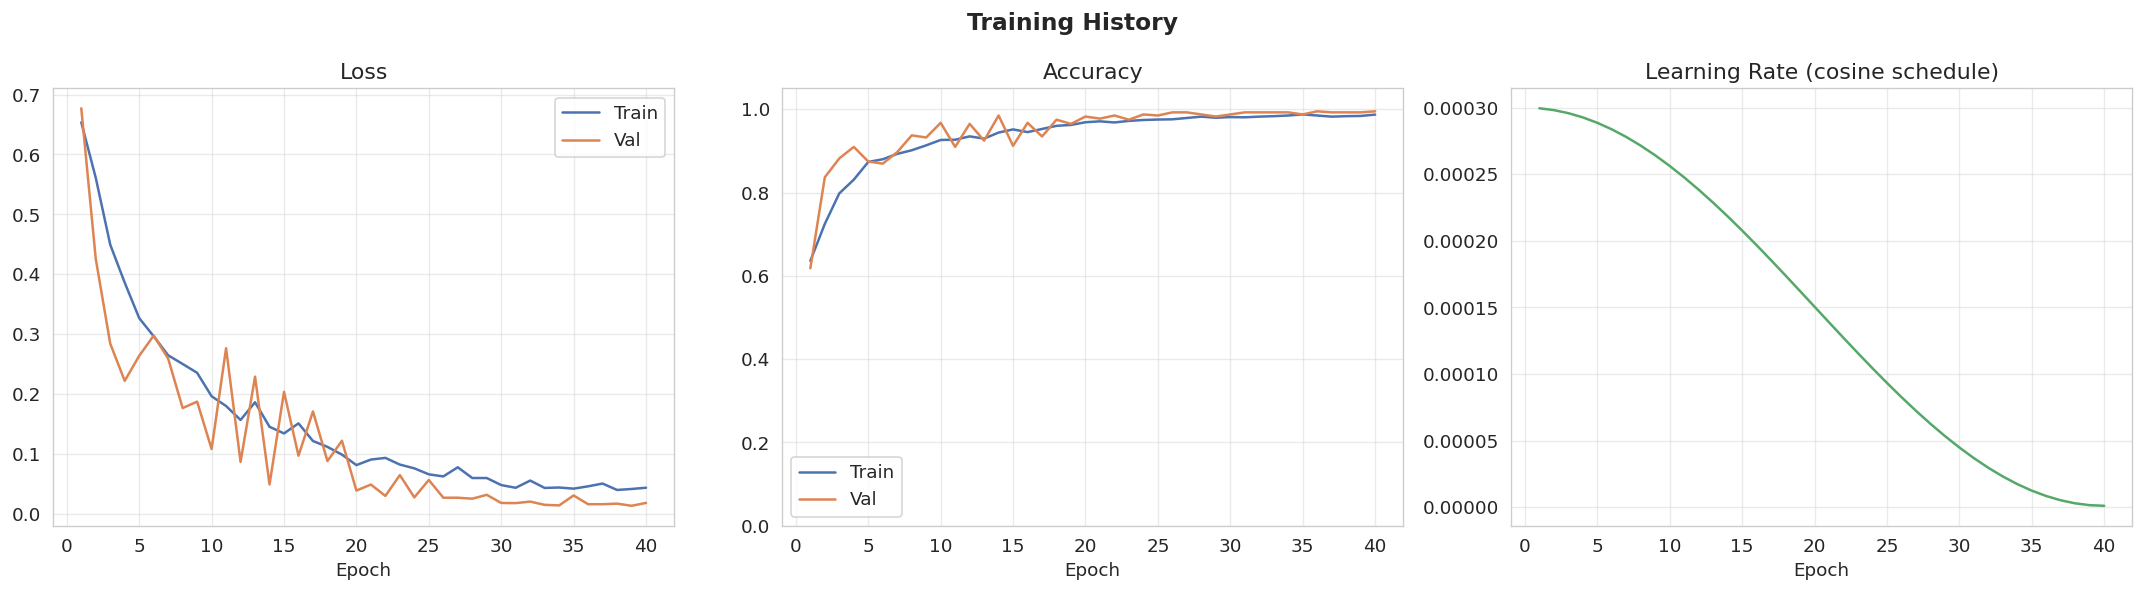

In [14]:
### 4.1 — Training curves

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training History", fontsize=14, fontweight="bold")
epochs_x = range(1, EPOCHS + 1)

axes[0].plot(epochs_x, history["train_loss"], label="Train", color="#4C72B0")
axes[0].plot(epochs_x, history["val_loss"],   label="Val",   color="#DD8452")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(epochs_x, history["train_acc"], label="Train", color="#4C72B0")
axes[1].plot(epochs_x, history["val_acc"],   label="Val",   color="#DD8452")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.4)

axes[2].plot(epochs_x, history["lr"], color="#55A868")
axes[2].set_title("Learning Rate (cosine schedule)")
axes[2].set_xlabel("Epoch")
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

In [15]:
### 4.2 — Test-set evaluation with best checkpoint

model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
model.eval()

all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        logits = model(x)
        probs  = torch.sigmoid(logits).cpu().numpy()
        preds  = (probs >= 0.5).astype(int)
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(y.numpy().astype(int).tolist())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)\n")
print(classification_report(all_labels, all_preds, target_names=["no_rain", "rain"]))

/tmp/ipykernel_415644/2405379584.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))


Test Accuracy: 1.0000  (100.00%)

              precision    recall  f1-score   support

     no_rain       1.00      1.00      1.00       182
        rain       1.00      1.00      1.00       216

    accuracy                           1.00       398
   macro avg       1.00      1.00      1.00       398
weighted avg       1.00      1.00      1.00       398



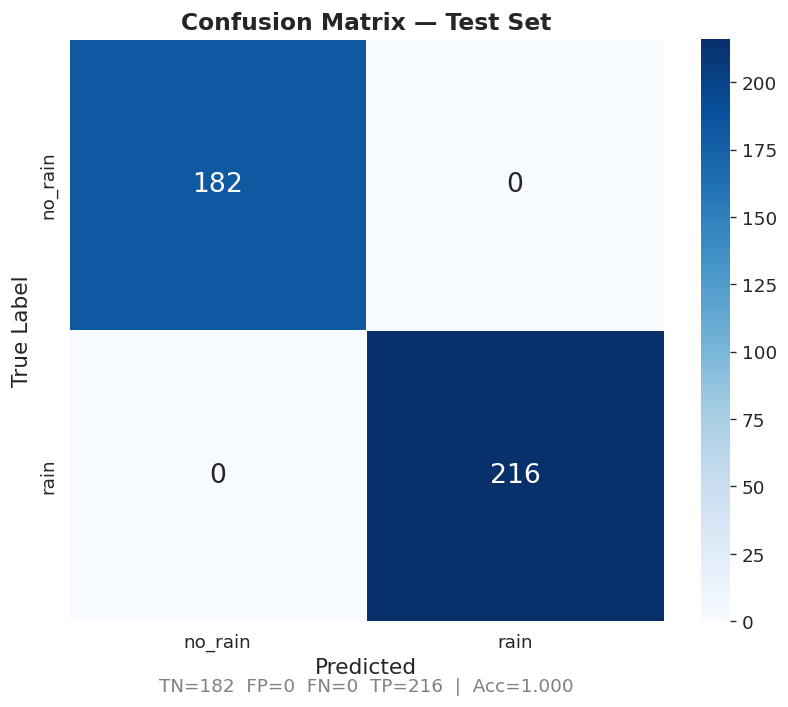

In [16]:
### 4.3 — Confusion matrix

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["no_rain", "rain"],
            yticklabels=["no_rain", "rain"],
            linewidths=0.5, ax=ax, annot_kws={"size": 16})
ax.set_xlabel("Predicted",  fontsize=13)
ax.set_ylabel("True Label", fontsize=13)
ax.set_title("Confusion Matrix — Test Set", fontsize=14, fontweight="bold")

tn, fp, fn, tp = cm.ravel()
ax.text(0.5, -0.12,
        f"TN={tn}  FP={fp}  FN={fn}  TP={tp}  |  Acc={test_acc:.3f}",
        ha="center", transform=ax.transAxes, fontsize=11, color="gray")
plt.tight_layout()
plt.show()

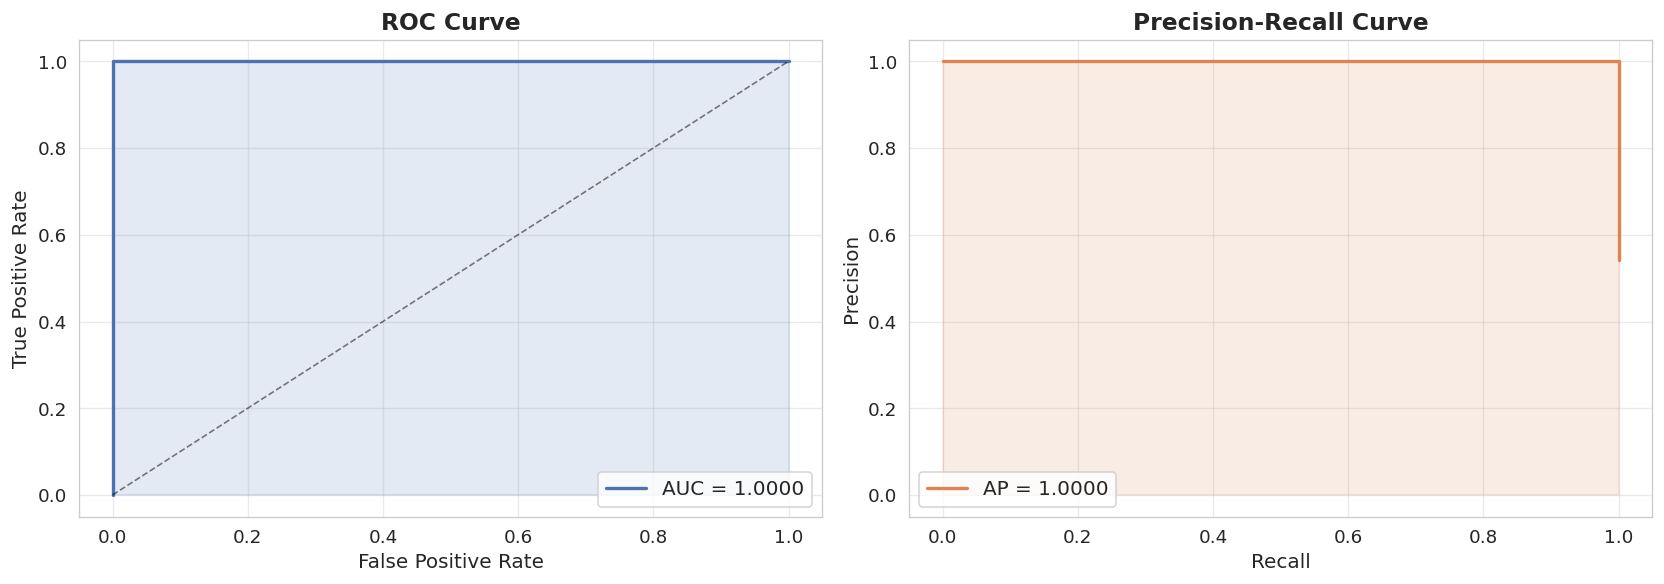

ROC-AUC: 1.0000   |   Average Precision: 1.0000


In [17]:
### 4.4 — ROC curve & Precision-Recall curve

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc     = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(all_labels, all_probs)
ap = average_precision_score(all_labels, all_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
axes[0].plot(fpr, tpr, color="#4C72B0", lw=2, label=f"AUC = {roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[0].fill_between(fpr, tpr, alpha=0.15, color="#4C72B0")
axes[0].set_xlabel("False Positive Rate", fontsize=12)
axes[0].set_ylabel("True Positive Rate", fontsize=12)
axes[0].set_title("ROC Curve", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.4)

# PR
axes[1].plot(recall, precision, color="#DD8452", lw=2, label=f"AP = {ap:.4f}")
axes[1].fill_between(recall, precision, alpha=0.15, color="#DD8452")
axes[1].set_xlabel("Recall",    fontsize=12)
axes[1].set_ylabel("Precision", fontsize=12)
axes[1].set_title("Precision-Recall Curve", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()
print(f"ROC-AUC: {roc_auc:.4f}   |   Average Precision: {ap:.4f}")

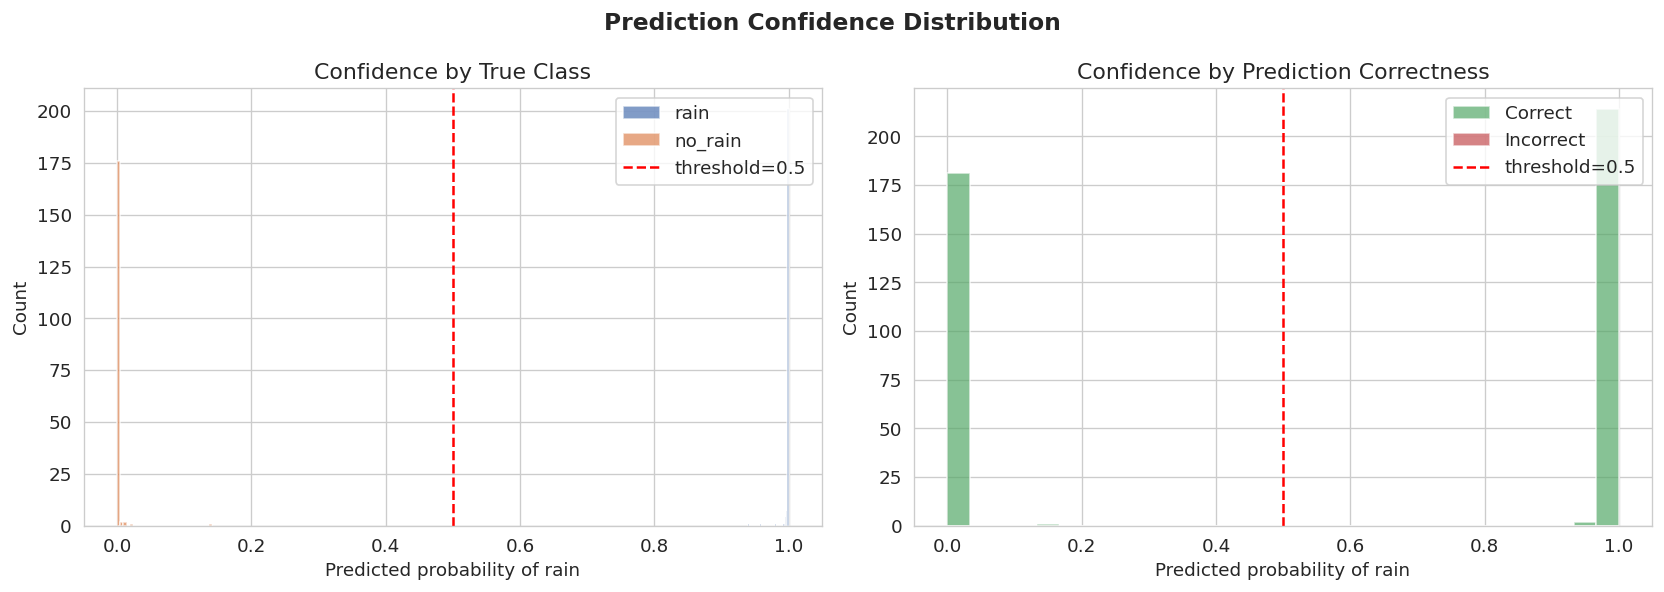

In [18]:
### 4.5 — Prediction confidence distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Prediction Confidence Distribution", fontsize=14, fontweight="bold")

for lbl, name, color in [(1, "rain", "#4C72B0"), (0, "no_rain", "#DD8452")]:
    mask = all_labels == lbl
    axes[0].hist(all_probs[mask], bins=30, alpha=0.7, color=color,
                 label=name, edgecolor="white")
axes[0].axvline(0.5, color="red", linestyle="--", label="threshold=0.5")
axes[0].set_xlabel("Predicted probability of rain")
axes[0].set_ylabel("Count")
axes[0].set_title("Confidence by True Class")
axes[0].legend()

correct_mask = all_preds == all_labels
axes[1].hist(all_probs[correct_mask],  bins=30, alpha=0.7, color="#55A868",
             label="Correct",   edgecolor="white")
axes[1].hist(all_probs[~correct_mask], bins=30, alpha=0.7, color="#C44E52",
             label="Incorrect", edgecolor="white")
axes[1].axvline(0.5, color="red", linestyle="--", label="threshold=0.5")
axes[1].set_xlabel("Predicted probability of rain")
axes[1].set_ylabel("Count")
axes[1].set_title("Confidence by Prediction Correctness")
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
### 4.6 — Qualitative inspection: hardest mistakes (highest-confidence wrong predictions)

errors_idx = np.where(all_preds != all_labels)[0]
if len(errors_idx) == 0:
    print("No errors on the test set!")
else:
    # sort by how wrong (confidence in the wrong direction)
    error_conf = np.abs(all_probs[errors_idx] - 0.5)
    sorted_err = errors_idx[np.argsort(error_conf)[::-1]]
    top_k = min(6, len(sorted_err))

    test_paths  = test_df["path"].tolist()
    test_labels = test_df["label_id"].tolist()

    fig, axes = plt.subplots(2, 3, figsize=(16, 7))
    fig.suptitle(f"Top-{top_k} Most Confident Errors", fontsize=14, fontweight="bold", color="#C44E52")

    for i, idx in enumerate(sorted_err[:top_k]):
        ax = axes[i // 3][i % 3]
        fp = test_paths[idx]
        y = load_wave(fp)
        mel = compute_mel(y) if False else librosa.power_to_db(
            librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT,
                                           hop_length=HOP_LENGTH, n_mels=N_MELS,
                                           fmin=FMIN, fmax=FMAX), ref=np.max)
        librosa.display.specshow(mel, sr=SR, hop_length=HOP_LENGTH,
                                  x_axis="time", y_axis="mel",
                                  fmin=FMIN, fmax=FMAX, ax=ax, cmap="magma")
        true_lbl = "rain" if all_labels[idx] == 1 else "no_rain"
        pred_lbl = "rain" if all_preds[idx]  == 1 else "no_rain"
        ax.set_title(f"True: {true_lbl}  |  Pred: {pred_lbl}  (p={all_probs[idx]:.3f})",
                     fontsize=9, color="#C44E52")
        ax.set_xlabel("")

    for j in range(top_k, 6):
        axes[j // 3][j % 3].axis("off")

    plt.tight_layout()
    plt.show()

No errors on the test set!


In [20]:
### 4.7 — Summary

best_val_acc = max(history["val_acc"])
best_epoch   = history["val_acc"].index(best_val_acc) + 1

summary = {
    "Total clips":        len(df),
    "Rain clips":         int((df.label == "rain").sum()),
    "No-rain clips":      int((df.label == "no_rain").sum()),
    "Train / Val / Test": f"{len(train_df)} / {len(val_df)} / {len(test_df)}",
    "Best val accuracy":  f"{best_val_acc:.4f}  (epoch {best_epoch})",
    "Test accuracy":      f"{test_acc:.4f}  ({test_acc*100:.2f}%)",
    "ROC-AUC":            f"{roc_auc:.4f}",
    "Average Precision":  f"{ap:.4f}",
}

print("=" * 45)
print("        RAIN DETECTION — SUMMARY")
print("=" * 45)
for k, v in summary.items():
    print(f"  {k:<25} {v}")
print("=" * 45)

        RAIN DETECTION — SUMMARY
  Total clips               2652
  Rain clips                1444
  No-rain clips             1208
  Train / Val / Test        1856 / 398 / 398
  Best val accuracy         0.9950  (epoch 36)
  Test accuracy             1.0000  (100.00%)
  ROC-AUC                   1.0000
  Average Precision         1.0000


In [22]:
### 5.1 — Save model + all inference config

import json
import torch
import os

EXPORT_DIR = "/home/amani/phd/rain_detection/export"
os.makedirs(EXPORT_DIR, exist_ok=True)

# ── 1. Save model weights ─────────────────────────────────────────────────────
model_path = os.path.join(EXPORT_DIR, "rain_cnn_best.pt")
torch.save(rt_model.state_dict(), model_path)
print(f"✅ Model weights saved → {model_path}")

# ── 2. Save all config needed for inference ───────────────────────────────────
config = {
    "SR":          SR,
    "DURATION":    DURATION,
    "N_MELS":      N_MELS,
    "N_FFT":       N_FFT,
    "HOP_LENGTH":  HOP_LENGTH,
    "FMIN":        FMIN,
    "FMAX":        FMAX,
    "THRESHOLD":   0.5,
}

config_path = os.path.join(EXPORT_DIR, "inference_config.json")
with open(config_path, "w") as f:
    json.dump(config, f, indent=4)
print(f"✅ Config saved        → {config_path}")

print("\n📦 Export contents:")
for k, v in config.items():
    print(f"   {k:<15} {v}")

✅ Model weights saved → /home/amani/phd/rain_detection/export/rain_cnn_best.pt
✅ Config saved        → /home/amani/phd/rain_detection/export/inference_config.json

📦 Export contents:
   SR              44100
   DURATION        4.0
   N_MELS          64
   N_FFT           2048
   HOP_LENGTH      1024
   FMIN            20
   FMAX            22050
   THRESHOLD       0.5


In [23]:
### Realtime inference — standalone loader (no training needed)

import json
import torch
import os

EXPORT_DIR = "/home/amani/phd/rain_detection/export"

# ── load config ───────────────────────────────────────────────────────────────
with open(os.path.join(EXPORT_DIR, "inference_config.json")) as f:
    cfg = json.load(f)

SR         = cfg["SR"]
DURATION   = cfg["DURATION"]
N_MELS     = cfg["N_MELS"]
N_FFT      = cfg["N_FFT"]
HOP_LENGTH = cfg["HOP_LENGTH"]
FMIN       = cfg["FMIN"]
FMAX       = cfg["FMAX"]
THRESHOLD  = cfg["THRESHOLD"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── load model ────────────────────────────────────────────────────────────────
# (RainCNN class must be defined or imported before this)
model = RainCNN().to(DEVICE)
model.load_state_dict(torch.load(
    os.path.join(EXPORT_DIR, "rain_cnn_best.pt"),
    map_location=DEVICE,
    weights_only=False
))
model.eval()
print(f"✅ Model ready on {DEVICE}")
print(f"   SR={SR}, N_FFT={N_FFT}, HOP={HOP_LENGTH}, N_MELS={N_MELS}")

✅ Model ready on cuda
   SR=44100, N_FFT=2048, HOP=1024, N_MELS=64


In [21]:
import sounddevice as sd
import threading, time, os
import scipy.io.wavfile as wav_write
import numpy as np, torch, librosa
from datetime import datetime

SAVE_ROOT   = "/home/amani/phd/rain_detection/processed_binary_4s/realtime_classical_segments"
DIR_RAIN    = os.path.join(SAVE_ROOT, "rain")
DIR_NO_RAIN = os.path.join(SAVE_ROOT, "no_rain")
os.makedirs(DIR_RAIN, exist_ok=True)
os.makedirs(DIR_NO_RAIN, exist_ok=True)

RT_DURATION  = 4
RT_INTERVAL  = 1
RT_THRESHOLD = 0.5
N_SAMPLES    = SR * RT_DURATION      # 44100 * 4 = 176400

rt_model = RainCNN().to(DEVICE)
rt_model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE, weights_only=False))
rt_model.eval()
print(f"✅ Model loaded")

def compute_mel(y):
    S  = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT,
             hop_length=HOP_LENGTH, n_mels=N_MELS, fmin=FMIN, fmax=FMAX)
    db = librosa.power_to_db(S, ref=np.max)
    db = (db - db.min()) / (db.max() - db.min() + 1e-8)
    return torch.tensor(db, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

audio_buffer = np.zeros(N_SAMPLES, dtype=np.float32)
buffer_lock  = threading.Lock()
stop_event   = threading.Event()

def audio_callback(indata, frames, time_info, status):
    chunk = indata[:, 0].astype(np.float32)
    n = len(chunk)
    with buffer_lock:
        audio_buffer[:-n] = audio_buffer[n:]  # in-place shift
        audio_buffer[-n:] = chunk

def classify_loop():
    seg_count = 0
    print("\n🎙️  Listening…  (run stop_event.set() to stop)\n")
    print(f"{'Time':^12}  {'Label':^12}  {'Confidence':^12}  {'Saved As'}")
    print("─" * 75)
    while not stop_event.is_set():
        time.sleep(RT_INTERVAL)
        with buffer_lock:
            clip = audio_buffer.copy()
        spec = compute_mel(clip).to(DEVICE)
        with torch.no_grad():
            prob = torch.sigmoid(rt_model(spec)).item()
        label     = "rain" if prob >= RT_THRESHOLD else "no_rail"
        seg_count += 1
        fname     = f"seg{seg_count:04d}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.wav"
        wav_write.write(os.path.join(DIR_RAIN if label=="rain" else DIR_NO_RAIN, fname),
                        SR, (clip * 32767).astype(np.int16))
        bar = "🌧️ " if label == "rain" else "☀️ "
        print(f"{datetime.now().strftime('%H:%M:%S'):^12}  {bar}{label:^10}  {prob:^12.3f}  {fname}")

stop_event.clear()
stream = sd.InputStream(
    device=1,
    samplerate=SR,                   # 44100 — matches model and device
    channels=1,
    dtype="float32",
    blocksize=int(SR * 0.1),         # 100ms chunks
    callback=audio_callback,
)
clf_thread = threading.Thread(target=classify_loop, daemon=True)

try:
    stream.start()
    clf_thread.start()
    print("▶️  Capturing at 44100 Hz → classifying")
    print("   Run  stop_event.set()  in a new cell to stop.\n")
except Exception as e:
    print(f"❌ {e}")
    stream.close()

✅ Model loaded
❌ Error starting stream: Wait timed out [PaErrorCode -9987]


Expression 'paTimedOut' failed in 'src/os/unix/pa_unix_util.c', line: 387
Expression 'PaUnixThread_New( &stream->thread, &CallbackThreadFunc, stream, 1., stream->rtSched )' failed in 'src/hostapi/alsa/pa_linux_alsa.c', line: 2998
Expression 'pthread_join( self->thread, &pret )' failed in 'src/os/unix/pa_unix_util.c', line: 441
Expression 'PaUnixThread_Terminate( &stream->thread, !abort, &threadRes )' failed in 'src/hostapi/alsa/pa_linux_alsa.c', line: 3102


In [9]:
try:
    stop_event.set()
    stream.stop()
    stream.close()
except: pass
import sounddevice as sd
sd.stop()

Expression 'pthread_join( self->thread, &pret )' failed in 'src/os/unix/pa_unix_util.c', line: 441
Expression 'PaUnixThread_Terminate( &stream->thread, !abort, &threadRes )' failed in 'src/hostapi/alsa/pa_linux_alsa.c', line: 3102
Expression 'pthread_join( self->thread, &pret )' failed in 'src/os/unix/pa_unix_util.c', line: 441
Expression 'PaUnixThread_Terminate( &stream->thread, !abort, &threadRes )' failed in 'src/hostapi/alsa/pa_linux_alsa.c', line: 3102


In [77]:
import sounddevice as sd
print(sd.query_devices())

  0 pulse, ALSA (32 in, 32 out)
* 1 default, ALSA (32 in, 32 out)


In [78]:
print(sd.query_devices(kind='input'))

{'name': 'default', 'index': 1, 'hostapi': 0, 'max_input_channels': 32, 'max_output_channels': 32, 'default_low_input_latency': 0.008707482993197279, 'default_low_output_latency': 0.008707482993197279, 'default_high_input_latency': 0.034829931972789115, 'default_high_output_latency': 0.034829931972789115, 'default_samplerate': 44100.0}


In [74]:
stop_event.set()
stream.stop()